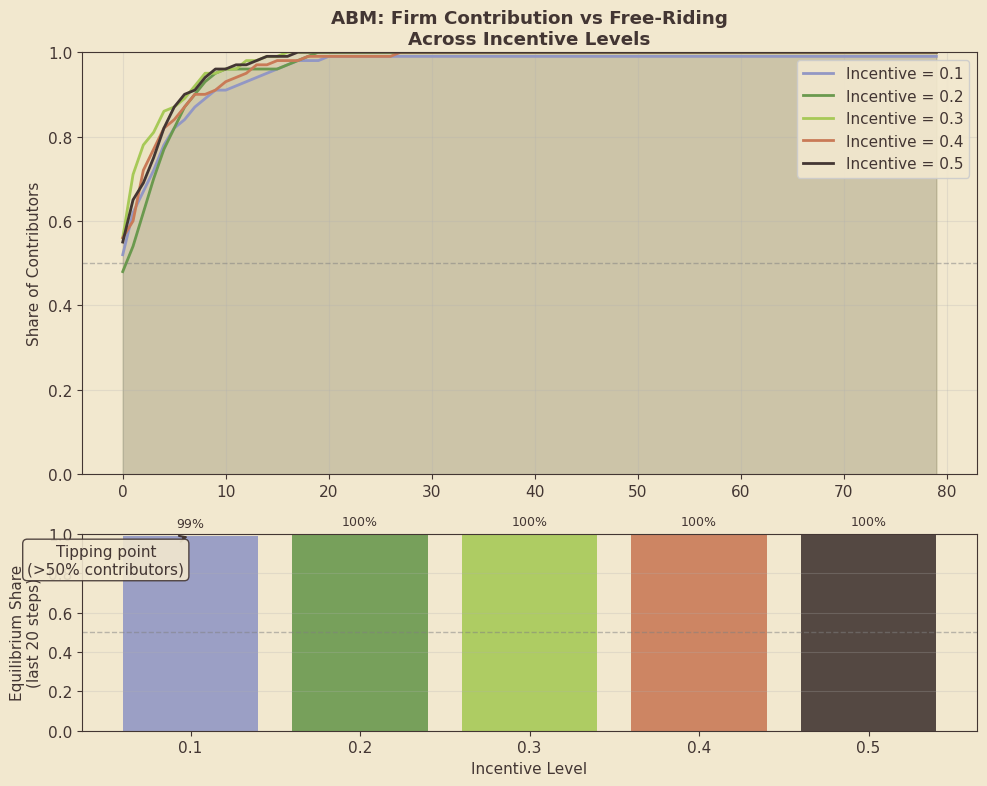

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

# ----- Styling (commons colour palette) -----
LAVENDER = "#9297C4"
FOREST   = "#6A994E"
LIME     = "#A7C957"
CREAM    = "#F2E8CF"
ESPRESSO = "#433633"

plt.rcParams.update({
    "figure.facecolor": CREAM,
    "axes.facecolor": CREAM,
    "axes.edgecolor": ESPRESSO,
    "axes.labelcolor": ESPRESSO,
    "text.color": ESPRESSO,
    "xtick.color": ESPRESSO,
    "ytick.color": ESPRESSO,
    "font.size": 11,
    "axes.titleweight": "bold"
})

# ----- ABM parameters -----
N_AGENTS = 100
N_STEPS = 80
FREE_RIDE_BENEFIT = 0.5
CONTRIBUTION_COST = 0.4
SWITCH_PROB = 0.2      # inertia: probability of switching per step
DECAY_RATE = 0.05      # how fast commons health adjusts

random.seed(42)
np.random.seed(42)

class Firm:
    def __init__(self, agent_id):
        self.id = agent_id
        self.state = random.choice(["contributor", "free-rider"])
        # Heterogeneous preference for contributing
        self.threshold = np.random.normal(loc=0.0, scale=0.08)

    def decide(self, commons_health, incentive):
        contrib_payoff = commons_health + incentive - CONTRIBUTION_COST + self.threshold
        freerider_payoff = commons_health * FREE_RIDE_BENEFIT

        wants_to_contribute = contrib_payoff > freerider_payoff

        # Inertia: only sometimes switch
        if wants_to_contribute and self.state == "free-rider":
            if random.random() < SWITCH_PROB:
                self.state = "contributor"
        elif not wants_to_contribute and self.state == "contributor":
            if random.random() < SWITCH_PROB:
                self.state = "free-rider"

def run_simulation(incentive, n_steps=N_STEPS):
    firms = [Firm(i) for i in range(N_AGENTS)]
    history = []
    health_history = []
    commons_health = 0.5  # start at neutral health

    for step in range(n_steps):
        # Decision phase
        for firm in firms:
            firm.decide(commons_health, incentive)

        contributor_share = sum(1 for f in firms if f.state == "contributor") / N_AGENTS

        # Commons health responds to contributions with some lag
        commons_health = commons_health * (1 - DECAY_RATE) + contributor_share * DECAY_RATE * 10
        commons_health = np.clip(commons_health, 0, 1)

        history.append(contributor_share)
        health_history.append(commons_health)

    return np.array(history), np.array(health_history)

# ----- Run model for several incentive levels -----
incentive_levels = [0.1, 0.2, 0.3, 0.4, 0.5]
colors = [LAVENDER, FOREST, LIME, "#c97a57", ESPRESSO]  # last two are complementary

results = {}
for inc in incentive_levels:
    contrib_hist, health_hist = run_simulation(incentive=inc)
    results[inc] = {
        "contrib": contrib_hist,
        "health": health_hist,
        "equilibrium": contrib_hist[-20:].mean()  # avg over last 20 steps
    }

# ----- Prepare plot -----
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 8),
    gridspec_kw={"height_ratios": [3, 1.4]}
)

# --- Top: time series of contributor share ---
for (inc, res), color in zip(results.items(), colors):
    ax1.plot(
        res["contrib"], label=f"Incentive = {inc:.1f}",
        color=color, linewidth=2
    )
    ax1.fill_between(
        range(N_STEPS), res["contrib"],
        color=color, alpha=0.08
    )

ax1.axhline(0.5, color="gray", linestyle="--", alpha=0.5, linewidth=1)
ax1.set_ylabel("Share of Contributors")
ax1.set_title("ABM: Firm Contribution vs Free-Riding\nAcross Incentive Levels")
ax1.set_ylim(0, 1)
ax1.grid(alpha=0.25)
ax1.legend(frameon=True, framealpha=0.9, facecolor=CREAM)

# --- Bottom: equilibrium contributor share (bar chart) ---
equilibria = [results[inc]["equilibrium"] for inc in incentive_levels]
bars = ax2.bar(
    [str(inc) for inc in incentive_levels],
    equilibria,
    color=colors, alpha=0.9
)

ax2.axhline(0.5, color="gray", linestyle="--", alpha=0.5, linewidth=1)
ax2.set_xlabel("Incentive Level")
ax2.set_ylabel("Equilibrium Share\n(last 20 steps)")
ax2.set_ylim(0, 1)
ax2.grid(axis="y", alpha=0.25)

# Annotate bars with percentages
for bar, eq in zip(bars, equilibria):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        eq + 0.03,
        f"{eq*100:.0f}%",
        ha="center", va="bottom", fontsize=9, color=ESPRESSO
    )

# Mark approximate tipping point (first incentive with eq >= 0.5)
tipping_idx = next((i for i, eq in enumerate(equilibria) if eq >= 0.5), None)
if tipping_idx is not None:
    ax2.annotate(
        "Tipping point\n(>50% contributors)",
        xy=(tipping_idx, equilibria[tipping_idx]),
        xytext=(tipping_idx - 0.5, 0.8),
        textcoords=("data", "data"),
        arrowprops=dict(
            arrowstyle="->",
            color=ESPRESSO,
            lw=1.5
        ),
        bbox=dict(boxstyle="round,pad=0.3", fc=CREAM, ec=ESPRESSO, alpha=0.9),
        ha="center"
    )

plt.tight_layout()
plt.show()